# Image Recognition

This notebook starts with a simple neural network for image recognition. First, we represent an image as a single sequence of numbers - a tensor. This helps us explore the limitations of that approach and see that the network is memorizing the training dataset rather than generalizing. Next, we define convolutions and kernels and improve the neural network to achieve better generalization.

Image recognition is arguably the task that made the world realize the potential of deep learning.

# Datasets

We are going to use a dataset called CIFAR-10. CIFAR-10 consists of 60,000 tiny 60x60 images, labeled with an integer corresponding to 1 of 10 classes: airplane (0), automobile (1), bird (2), cat (3), deer (4), dog (5), frog (6), horse (7), ship (8), and truck (9). We use `torchvision` module to automatically download the dataset and load it as a collection of tensors.

In [1]:
from torchvision import datasets

In [2]:
cifar10 = datasets.CIFAR10("data/", train=True, download=True)
cifar10_val = datasets.CIFAR10("data/", train=False, download=True)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170M/170M [00:34<00:00, 4.96MB/s]


In [3]:
cifar10

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data/
    Split: Train

In [4]:
cifar10_val

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: data/
    Split: Test

Just like CIFAR10, the datasets submodule gives us ready-made access to the most popular computer vision datasets, such as MNIST, Fashion-MNIST, CIFAR-100, SVHN, COCO, and Omniglot. In each case, the dataset is returned as a subclass of `torch.utils.data.Dataset`.

A dataset is an object that should have two methods implemented:

- `__len()__`
- `__getitem()__`

In [5]:
len(cifar10)  # call __len__()

50000

In [25]:
img, img_class_id = cifar10[42]  # call __getitem()__

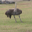

In [32]:
img

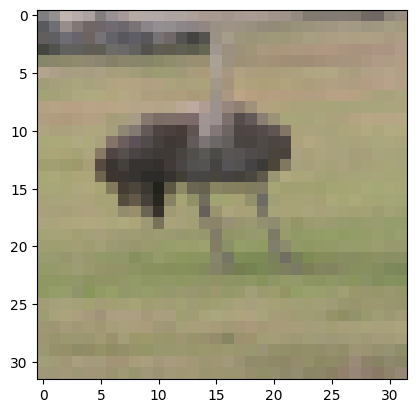

In [33]:
import matplotlib.pyplot as plt
plt.imshow(img)

In [34]:
cifar10.classes[img_class_id]  # all image classes are stored in "classes" variable

'bird'

# Transforms

We need to convert images to PyTorch tensors before we can do anything with them. We can do that with `torchvision.transforms`.

In [35]:
from torchvision import transforms

In [38]:
dir(transforms)

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

In [43]:
# One of the functions is `ToTensor`
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
print(img_t.shape); print(img_t)

torch.Size([3, 32, 32])
tensor([[[0.4980, 0.5804, 0.7529,  ..., 0.4392, 0.5647, 0.6000],
         [0.3490, 0.4353, 0.5922,  ..., 0.6314, 0.6510, 0.6392],
         [0.3843, 0.3686, 0.4314,  ..., 0.6784, 0.6627, 0.6784],
         ...,
         [0.6118, 0.5922, 0.5843,  ..., 0.5882, 0.5843, 0.5569],
         [0.6392, 0.6353, 0.6314,  ..., 0.5294, 0.5529, 0.5412],
         [0.6275, 0.6275, 0.6392,  ..., 0.5412, 0.5608, 0.5922]],

        [[0.4941, 0.5647, 0.7098,  ..., 0.4000, 0.5294, 0.5569],
         [0.3529, 0.4314, 0.5529,  ..., 0.5961, 0.6196, 0.6039],
         [0.3686, 0.3686, 0.4275,  ..., 0.6235, 0.6039, 0.6157],
         ...,
         [0.5961, 0.5686, 0.5647,  ..., 0.5647, 0.5804, 0.5608],
         [0.6196, 0.6078, 0.5922,  ..., 0.5137, 0.5373, 0.5255],
         [0.5961, 0.5922, 0.6000,  ..., 0.4745, 0.5137, 0.5294]],

        [[0.5059, 0.5647, 0.6863,  ..., 0.3843, 0.4824, 0.5098],
         [0.3686, 0.4549, 0.5373,  ..., 0.5059, 0.5176, 0.5020],
         [0.3686, 0.3882, 0.4627, 

In [44]:
# We can also pass `transform` directly when we read a dataset
cifar10_t = datasets.CIFAR10("data/", train=True, download=True, 
                             transform=transforms.ToTensor())
cifar10_val_t = datasets.CIFAR10("data/", train=False, download=True,
                                transform=transforms.ToTensor())

In [52]:
t, t_class_id = cifar10_t[42]
print(f"{t.shape} -> {t.dtype}"); print(t); print(t_class_id)

torch.Size([3, 32, 32]) -> torch.float32
tensor([[[0.4980, 0.5804, 0.7529,  ..., 0.4392, 0.5647, 0.6000],
         [0.3490, 0.4353, 0.5922,  ..., 0.6314, 0.6510, 0.6392],
         [0.3843, 0.3686, 0.4314,  ..., 0.6784, 0.6627, 0.6784],
         ...,
         [0.6118, 0.5922, 0.5843,  ..., 0.5882, 0.5843, 0.5569],
         [0.6392, 0.6353, 0.6314,  ..., 0.5294, 0.5529, 0.5412],
         [0.6275, 0.6275, 0.6392,  ..., 0.5412, 0.5608, 0.5922]],

        [[0.4941, 0.5647, 0.7098,  ..., 0.4000, 0.5294, 0.5569],
         [0.3529, 0.4314, 0.5529,  ..., 0.5961, 0.6196, 0.6039],
         [0.3686, 0.3686, 0.4275,  ..., 0.6235, 0.6039, 0.6157],
         ...,
         [0.5961, 0.5686, 0.5647,  ..., 0.5647, 0.5804, 0.5608],
         [0.6196, 0.6078, 0.5922,  ..., 0.5137, 0.5373, 0.5255],
         [0.5961, 0.5922, 0.6000,  ..., 0.4745, 0.5137, 0.5294]],

        [[0.5059, 0.5647, 0.6863,  ..., 0.3843, 0.4824, 0.5098],
         [0.3686, 0.4549, 0.5373,  ..., 0.5059, 0.5176, 0.5020],
         [0.3686,

Interesting observation: values in the original PIL image ranged from 0 to 255 (8 bits per channel), while `ToTensor` transform turns data into 32-bit float per channel and scales the values from 0 to 1.

In [55]:
import torch

In [59]:
print(f"min(t) = {torch.min(t)}, max(t) = {torch.max(t)}")

min(t) = 0.10980392247438431, max(t) = 0.7529411911964417


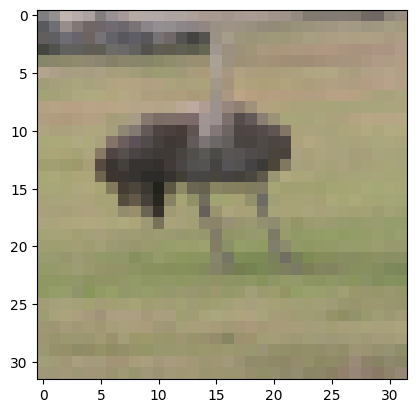

In [65]:
# We can print the original image by arranging showing channel
plt.imshow(img_t.permute(1, 2, 0))
plt.show()

We can also chain transforms with `transforms.Compose`, for example for normalization or data augmentation, directly in the data loader. For instance, it’s good practice to normalize the dataset so that each channel has zero mean and unitary standard deviation.